In [2]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [4]:
import os
import torch
import matplotlib.pyplot as plt
import scienceplots
from torchvision.transforms import transforms
from tqdm import tqdm
from project.models import EDMMauMau, EDMSerie
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE
from project.util.filters import MedianFilter

In [14]:
GAME = "Breakout"
PATH = os.path.join("..", "checkpoints", "diff", f"{GAME}.pt")
DATA = os.path.join("..", "checkpoints", "memory", f"{GAME}.pt")
OUTPUT = os.path.join("..", "results", "denoising", f"denoise_{GAME}.svg")
N = 8
SIGMA_NOISE_START = 0.1
SIGMA_NOISE_END = 1
NOISE_LEVELS = 9
SAMPLES = 100

In [6]:
plt.style.use(['science','no-latex', 'nature'])

In [7]:
device = "mps"

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [9]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [11]:
psnrs_naive = torch.zeros((NOISE_LEVELS, SAMPLES))
psnrs_full= torch.zeros_like(psnrs_naive)
psnrs_median = torch.zeros_like(psnrs_naive)

mses_naive = torch.zeros_like(psnrs_naive)
mses_full = torch.zeros_like(psnrs_naive)
mses_median = torch.zeros_like(psnrs_naive)

x = torch.zeros((SAMPLES, 4, 88, 88), device=device)

for i, img in enumerate(torch.randperm(500_000)[:SAMPLES]):
    x[i] = data[img].to(device)

sigmas = torch.linspace(SIGMA_NOISE_START, SIGMA_NOISE_END, NOISE_LEVELS)

model_full = EDMSerie.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START, N=N).to(device)
model_naive = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START).to(device)

filter = MedianFilter()

for i, sigma in enumerate(sigmas):

    model_full.set_sigma_noise(sigma)
    model_naive.set_sigma_noise(sigma)

    e = sigma * torch.randn_like(x)
    x_noisy = x + e

    with torch.no_grad():

        x_denoised_full = model_full.denoise(x_noisy)
        x_denoised_naive = model_naive.denoise(x_noisy)
        x_denoised_median = filter.denoise(x_noisy.to("cpu"))

        for j in tqdm(range(SAMPLES), desc="samples"):

            psnrs_full[i, j] = PSNR(x[j].to("cpu"), x_denoised_full[j].to("cpu"), torch.tensor(2).to("cpu"))
            psnrs_naive[i, j] = PSNR(x[j].to("cpu"), x_denoised_naive[j].to("cpu"), torch.tensor(2).to("cpu"))
            psnrs_median[i, j] = PSNR(x[j].to("cpu"), x_denoised_median[j].to("cpu"), torch.tensor(2).to("cpu"))

            mses_full[i, j] = MSE(x[j].to("cpu"), x_denoised_full[j].to("cpu"))
            mses_naive[i, j] = MSE(x[j].to("cpu"), x_denoised_naive[j].to("cpu"))
            mses_median[i, j] = MSE(x[j].to("cpu"), x_denoised_median[j].to("cpu"))

samples: 100%|██████████| 100/100 [00:00<00:00, 579.18it/s]


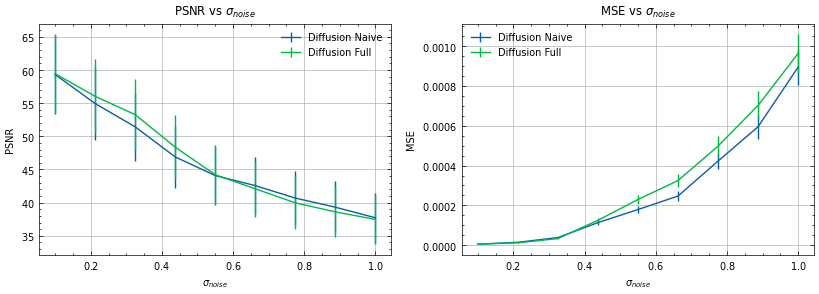

In [16]:
Ns = torch.arange(2, 33)

fig, axis = plt.subplots(1, 2, figsize=(10, 3), sharex=True)

# axis[0].errorbar(
#     sigmas, 
#     psnrs_median.mean(axis=1), 
#     psnrs_median.mean(axis=1) / SAMPLES ** 0.5,
#     label="Median Filter"
# )
axis[0].errorbar(
    sigmas, 
    psnrs_naive.mean(axis=1), 
    psnrs_naive.mean(axis=1) / SAMPLES ** 0.5,
    label="Diffusion Naive"
)
axis[0].errorbar(
    sigmas, 
    psnrs_full.mean(axis=1), 
    psnrs_full.mean(axis=1) / SAMPLES ** 0.5,
    label="Diffusion Full"
)
axis[0].set_xlabel("$\\sigma_{noise}$")
axis[0].set_ylabel("PSNR")
axis[0].set_title("PSNR vs $\\sigma_{noise}$")
axis[0].grid()
axis[0].legend()

# axis[1].errorbar(
#     sigmas, 
#     mses_median.mean(axis=1), 
#     mses_median.mean(axis=1) / SAMPLES ** 0.5,
#     label="Median Filter"
# )
axis[1].errorbar(
    sigmas, 
    mses_naive.mean(axis=1), 
    mses_naive.mean(axis=1) / SAMPLES ** 0.5,
    label="Diffusion Naive",
    fmt="r--"
)
axis[1].errorbar(
    sigmas, 
    mses_full.mean(axis=1), 
    mses_full.mean(axis=1) / SAMPLES ** 0.5,
    label="Diffusion Full",
    fmt="r--"
)
axis[1].set_xlabel("$\\sigma_{noise}$")
axis[1].set_ylabel("MSE")
axis[1].set_title("MSE vs $\\sigma_{noise}$")
axis[1].grid()
axis[1].legend()

plt.savefig(OUTPUT)
plt.show()